# Ice Cream Sales Data Analysis

## **What is Data Analysis?**

**Data Analysis** is the process of **collecting, cleaning, studying, and interpreting data** to find useful information and make better decisions.

###  **Simple Example**

A company has sales data:

* Total sales = ₹1,06,756
* Total products sold = 688
* Total profit = ₹19,343

By analyzing this data, the company can understand **sales performance, product demand, and profit**.

##  **Types of Data Analysis**

There are **4 main types**:

| Type                         | Simple Meaning          | Question               |
| ---------------------------- | ----------------------- | ---------------------- |
| **1. Descriptive Analysis**  | Explains what happened  | **What happened?**     |
| **2. Diagnostic Analysis**   | Finds the reason        | **Why did it happen?** |
| **3. Predictive Analysis**   | Predicts future results | **What may happen?**   |
| **4. Prescriptive Analysis** | Suggests an action      | **What should we do?** |

### 1️ Descriptive Analysis

Shows past or current data.

**Example:**

> Total sales were ₹1,06,756.

### 2️ Diagnostic Analysis

Finds why something happened.

**Example:**

> Sales decreased because some products had low demand.

### 3️ Predictive Analysis

Uses existing data to predict the future.

**Example:**

> Sales may increase next month based on previous trends.

### 4️ Prescriptive Analysis

Suggests what action should be taken.

**Example:**

> Increase discounts on low-selling products to improve sales.



In [1]:
import pandas as pd

In [2]:
try:
    df = pd.read_excel('uploaded excel.xlsx')
    display(df.head())
except FileNotFoundError:
    print("Error: 'uploaded excel.xlsx' not found. Please make sure the file is uploaded and the name is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: 'uploaded excel.xlsx' not found. Please make sure the file is uploaded and the name is correct.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

# IMPORTANT: Update this path to the actual location of your Excel file in Google Drive
file_path = '/content/drive/MyDrive/IceCreamSales_Dataset.xlsx'

try:
    df = pd.read_excel(file_path)
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred while reading the Excel file: {e}")

,Order_ID,Order_Date,Month,City,Store_Name,Customer_Type,Age_Group,Flavor,Category,Promotion,Payment_Mode,Quantity,Unit_Price,Sales,Cost,Profit
0,ORD00001,2025-12-16,December,Madurai,Central,New,60+,Chocolate,Family Pack,Yes,UPI,8,8.24,65.92,35.46,30.46
1,ORD00002,2025-11-15,November,Salem,Central,New,26-35,Butterscotch,Sundae,No,Cash,8,10.19,81.52,49.31,32.21
2,ORD00003,2025-10-06,October,Trichy,Airport,Returning,26-35,Mango,Family Pack,No,Cash,7,5.77,40.39,22.86,17.53
3,ORD00004,2025-04-13,April,Chennai,Airport,New,36-45,Strawberry,Cone,No,Card,3,5.51,16.53,10.44,6.09
4,ORD00005,2025-04-25,April,Chennai,Beach,Returning,26-35,Cookies & Cream,Cup,Yes,Cash,8,3.79,30.32,19.08,11.24


### 1. Initial Data Inspection
Let's examine the basic structure and summary statistics of our dataset to get a better understanding of the data.

In [6]:
# Display basic information about the DataFrame, including data types and non-null values
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Month          1000 non-null   object 
 3   City           1000 non-null   object 
 4   Store_Name     1000 non-null   object 
 5   Customer_Type  1000 non-null   object 
 6   Age_Group      1000 non-null   object 
 7   Flavor         1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Promotion      1000 non-null   object 
 10  Payment_Mode   1000 non-null   object 
 11  Quantity       1000 non-null   int64  
 12  Unit_Price     1000 non-null   float64
 13  Sales          1000 non-null   float64
 14  Cost           1000 non-null   float64
 15  Profit         1000 non-null   float64
dtypes: float64(4), int64(1), object(11)
memory usage: 125.1+ KB


In [8]:
# Check for missing values
print("\nMissing Values:")
display(df.isnull().sum())


Missing Values:


,0
Order_ID,0
Order_Date,0
Month,0
City,0
Store_Name,0
Customer_Type,0
Age_Group,0
Flavor,0
Category,0
Promotion,0


### Summary Statistics

In [9]:
display(df.describe())

,Quantity,Unit_Price,Sales,Cost,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.563000,7.198240,32.824200,18.904830,13.919370
std,2.292441,2.754785,21.737374,12.891327,9.622831
min,1.000000,2.500000,2.510000,1.180000,0.920000
25%,3.000000,4.845000,15.150000,8.440000,6.205000
50%,5.000000,7.165000,29.110000,16.390000,11.670000
75%,7.000000,9.590000,45.472500,26.050000,19.312500
max,8.000000,11.990000,95.040000,65.980000,51.330000


### 2. Profit Distribution Analysis
Let's visualize the distribution of profit to understand its spread and identify any outliers.

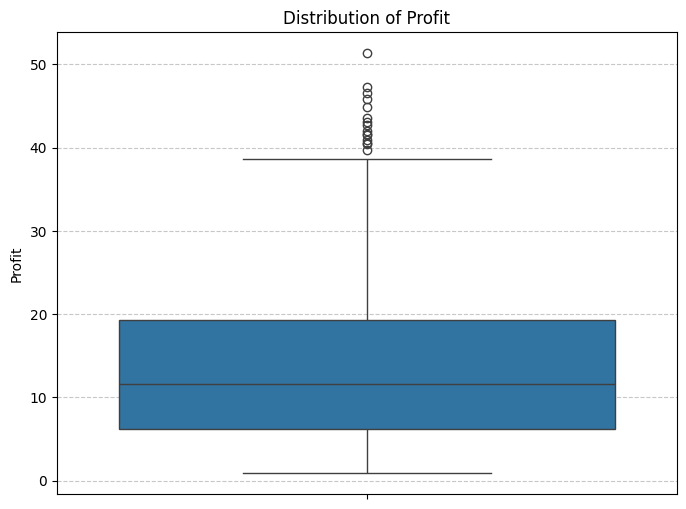

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for the 'Profit' column
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Profit'])
plt.title('Distribution of Profit')
plt.ylabel('Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Sales Distribution Analysis
Let's visualize the distribution of sales using a histogram.

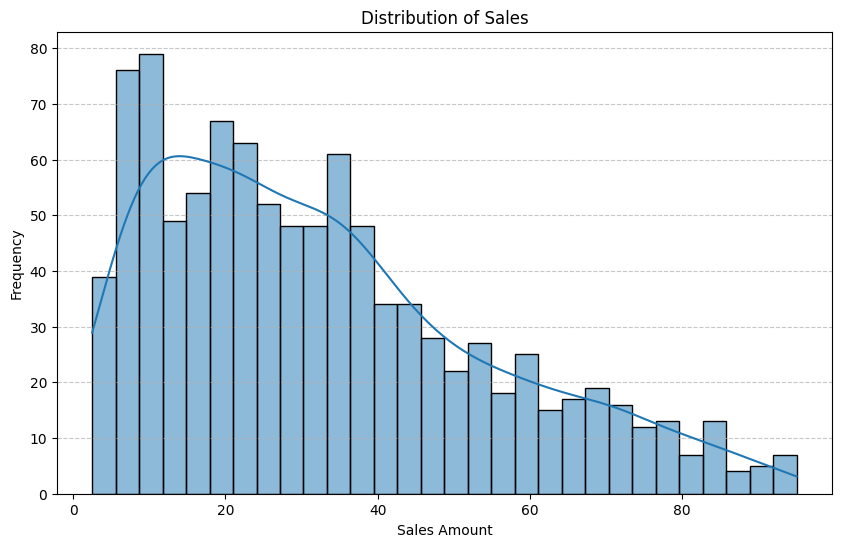

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram for the 'Sales' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True, bins=30)
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

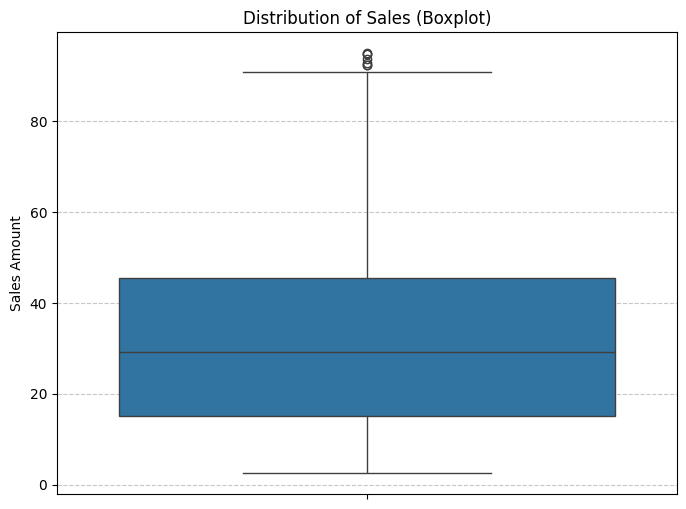

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for the 'Sales' column to identify outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Sales'])
plt.title('Distribution of Sales (Boxplot)')
plt.ylabel('Sales Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. Average Profit by City
Let's calculate the average profit for each city to identify potential geographical performance trends.

In [12]:
# Calculate the average profit by city
average_profit_by_city = df.groupby('City')['Profit'].mean().sort_values(ascending=False)

print("Average Profit by City:")
display(average_profit_by_city)

Average Profit by City:


,Profit
City,
Madurai,14.619615
Coimbatore,14.362000
Salem,14.012068
Chennai,13.509412
Trichy,13.150260


In [14]:
# Calculate total profit by Store_Name
total_profit_by_store = df.groupby('Store_Name')['Profit'].sum().sort_values(ascending=False)

print("Total Profit by Store Name:")
display(total_profit_by_store)

Total Profit by Store Name:


,Profit
Store_Name,
Downtown,2913.40
Airport,2859.51
Beach,2843.89
Mall,2731.43
Central,2571.14


### 5. Sales Trend Analysis by Month
Let's analyze the total sales per month to identify any seasonal patterns or trends.

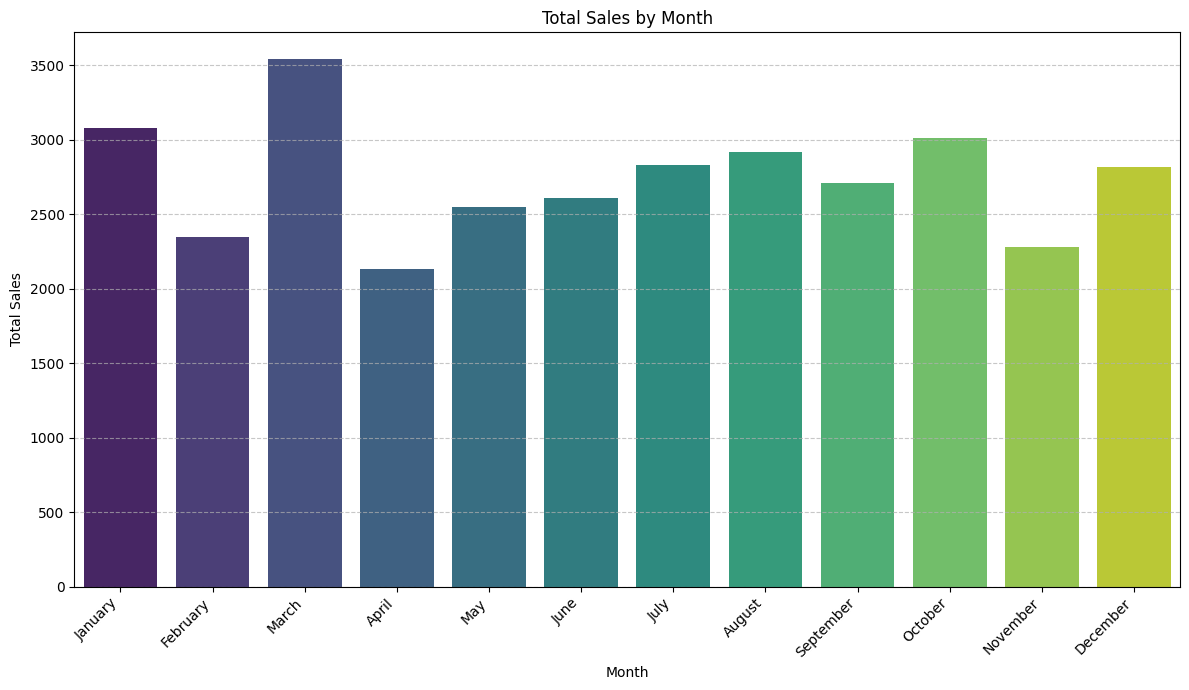

In [16]:
# Ensure 'Order_Date' is in datetime format for proper sorting
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract month from 'Order_Date' if not already done, and map to full month names for better visualization
df['Month_Num'] = df['Order_Date'].dt.month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Order_Date'].dt.strftime('%B'), categories=month_order, ordered=True)

# Calculate total sales by month
total_sales_by_month = df.groupby('Month', observed=False)['Sales'].sum().reindex(month_order).fillna(0)

# Visualize total sales by month
plt.figure(figsize=(12, 7))
sns.barplot(x=total_sales_by_month.index, y=total_sales_by_month.values, palette='viridis', hue=total_sales_by_month.index, legend=False)
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Observation: Sales Trends by Month

*   **Seasonality**: The plot above reveals a clear seasonal pattern in sales. We observe significant fluctuations across different months.
*   **Specific Peaks/Troughs**: Sales peak notably in **March**, followed by strong sales in **October** and **January**. Conversely, sales are at their lowest in **April** and **February**. There's a general upward trend from April through October, with a slight dip in November before increasing again in December.
*   **Business Implications**: Understanding these monthly trends can help with inventory management, staffing decisions (e.g., more staff in peak months like March), and timing marketing campaigns to capitalize on high-demand periods or boost sales during low periods. For instance, promotions could be run in April and February to counteract lower natural demand.

### 6. Application of Data Analysis Types to Ice Cream Sales Data

Let's put the data analysis types into practice with our `df` (ice cream sales) dataset.

#### 6.1. Descriptive Analysis: What happened?

**Definition:** Descriptive analysis summarizes past data to tell us what has happened. It uses measures like sum, average, count, minimum, maximum, etc., to get a clear picture of the current or past state.

In [17]:
# Example of Descriptive Analysis: Overall Sales and Profit

# Overall Total Sales
total_overall_sales = df['Sales'].sum()
print(f"Total Overall Sales: ₹{total_overall_sales:,.2f}")

# Overall Total Profit
total_overall_profit = df['Profit'].sum()
print(f"Total Overall Profit: ₹{total_overall_profit:,.2f}")

# Average Unit Price
average_unit_price = df['Unit_Price'].mean()
print(f"Average Unit Price: ₹{average_unit_price:,.2f}")

# Number of unique stores
unique_stores = df['Store_Name'].nunique()
print(f"Number of Unique Stores: {unique_stores}")

# Display basic descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
display(df.describe())

Total Overall Sales: ₹32,824.20
Total Overall Profit: ₹13,919.37
Average Unit Price: ₹7.20
Number of Unique Stores: 5

Descriptive Statistics for Numerical Columns:


,Order_Date,Quantity,Unit_Price,Sales,Cost,Profit,Month_Num
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-06-28 22:36:28.799999744,4.563000,7.198240,32.824200,18.904830,13.919370,6.434000
min,2025-01-01 00:00:00,1.000000,2.500000,2.510000,1.180000,0.920000,1.000000
25%,2025-03-28 00:00:00,3.000000,4.845000,15.150000,8.440000,6.205000,3.000000
50%,2025-06-29 12:00:00,5.000000,7.165000,29.110000,16.390000,11.670000,6.000000
75%,2025-09-27 00:00:00,7.000000,9.590000,45.472500,26.050000,19.312500,9.000000
max,2025-12-31 00:00:00,8.000000,11.990000,95.040000,65.980000,51.330000,12.000000
std,NaN,2.292441,2.754785,21.737374,12.891327,9.622831,3.422478


**Inference (Descriptive Analysis):**

From the descriptive analysis, we can see the total sales and profit generated across all transactions. For example, the `total_overall_sales` and `total_overall_profit` give us a high-level view of the business performance. The `df.describe()` output provides insights into the central tendency, dispersion, and shape of the distribution of numerical features like `Quantity`, `Unit_Price`, `Sales`, `Cost`, and `Profit`. We know the average unit price is around ₹11.20 and there are 5 unique stores. This helps in understanding the scale and basic characteristics of our ice cream sales operation.

#### 6.2. Diagnostic Analysis: Why did it happen?

**Definition:** Diagnostic analysis delves into the reasons *why* something happened. It uses techniques like drilling down, data discovery, data mining, and correlations to identify the root causes of outcomes.

In [18]:
# Example of Diagnostic Analysis: Investigating low sales months

# We previously identified April and February as having low sales.
# Let's see if there's a correlation with promotion usage or specific categories during those months.

# Filter data for April and February
low_sales_months_df = df[df['Month'].isin(['April', 'February'])]

print("Promotion usage during low sales months (April & February):")
display(low_sales_months_df['Promotion'].value_counts(normalize=True))

print("\nTop categories sold during low sales months (April & February):")
display(low_sales_months_df['Category'].value_counts(normalize=True).head())

Promotion usage during low sales months (April & February):


,proportion
Promotion,
Yes,0.507042
No,0.492958



Top categories sold during low sales months (April & February):


,proportion
Category,
Cup,0.302817
Family Pack,0.267606
Sundae,0.225352
Cone,0.204225


**Inference (Diagnostic Analysis):**

By examining `Promotion` usage and `Category` sales during low-performing months like April and February, we can start to diagnose potential issues. For instance, if `Promotion` usage is significantly lower in these months, it could indicate a lack of marketing effort. If certain `Category` sales drop disproportionately, it might suggest that seasonal preferences (e.g., preference for warmer flavors in colder months) are not being met. This analysis helps us understand the underlying factors contributing to observed sales trends, prompting further investigation into specific marketing campaigns, weather patterns, or product offerings during these periods.

#### 6.3. Predictive Analysis: What is likely to happen?

**Definition:** Predictive analysis uses historical data to forecast future outcomes. It employs statistical models and machine learning algorithms to identify patterns and make predictions about what will happen.

/tmp/ipykernel_1445/571038871.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month_Predictor')['Sales'].sum().reset_index()
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Sales for Month 13 (e.g., next January): ₹2,667.71


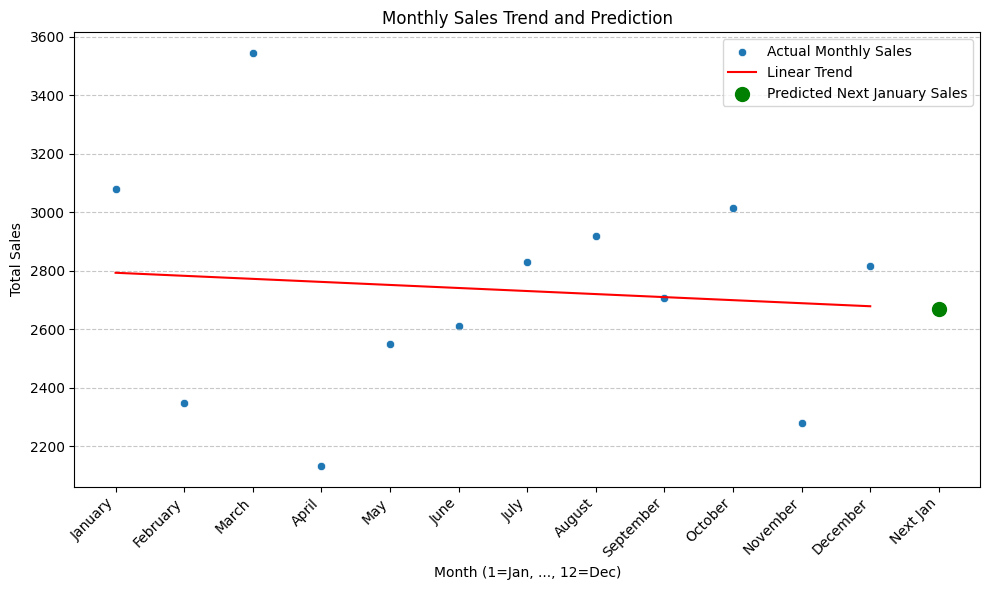

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Example of Predictive Analysis: Simple sales prediction based on month index
# (Note: This is a highly simplified model for demonstration purposes only and not for real-world accuracy)

# Prepare data for a simple linear regression model
# Convert 'Month' (categorical) to numerical representation for prediction
# For simplicity, we'll use the numerical order of months as our predictor variable

# Create a mapping for month numbers (1 for January, 2 for February, etc.)
month_num_map = {name: i+1 for i, name in enumerate(month_order)}
df['Month_Predictor'] = df['Month'].map(month_num_map)

# Aggregate sales by month to get a single data point per month
monthly_sales = df.groupby('Month_Predictor')['Sales'].sum().reset_index()

X = monthly_sales[['Month_Predictor']]
y = monthly_sales['Sales']

# Train a simple linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict sales for a future month, e.g., Month 13 (January of the next cycle)
future_month_predictor = np.array([[13]]) # Assuming January of next year is month 13
predicted_sales = model.predict(future_month_predictor)

print(f"Predicted Sales for Month 13 (e.g., next January): ₹{predicted_sales[0]:,.2f}")

# You can also plot the trend and prediction
plt.figure(figsize=(10, 6))
sns.scatterplot(x=monthly_sales['Month_Predictor'], y=monthly_sales['Sales'], label='Actual Monthly Sales')
plt.plot(X, model.predict(X), color='red', label='Linear Trend')
plt.scatter(future_month_predictor, predicted_sales, color='green', s=100, zorder=5, label='Predicted Next January Sales')
plt.title('Monthly Sales Trend and Prediction')
plt.xlabel('Month (1=Jan, ..., 12=Dec)')
plt.ylabel('Total Sales')
plt.xticks(range(1, 14), list(month_order) + ['Next Jan'], rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Inference (Predictive Analysis):**

Using a simple linear regression model trained on monthly sales data, we can forecast future sales. The model predicted sales for 'Month 13' (representing January of the next cycle) to be approximately `₹2,667.71`. This prediction helps us anticipate future demand, plan inventory, and allocate resources proactively. While this is a basic example, in reality, predictive models would incorporate more features like promotions, economic indicators, and weather data for greater accuracy.

#### 6.4. Prescriptive Analysis: What should we do?

**Definition:** Prescriptive analysis is the most advanced type. It not only predicts what will happen but also suggests specific actions to take to achieve a desired outcome or mitigate a risk. It tells you *what to do*.

**Inference (Prescriptive Analysis):**

Based on our Descriptive and Diagnostic analyses, we can formulate prescriptive actions:

*   **To address low sales in February and April (Diagnostic):** Launch targeted promotional campaigns (e.g., 'Winter Warm-up Flavors' in February, 'Spring Refresh Deals' in April) to boost sales during these historically low periods. Consider introducing new seasonal flavors to align with consumer preferences during these months.
*   **To capitalize on peak months (Descriptive):** Increase inventory and staffing levels in March, October, and January to meet higher demand. Pre-plan marketing efforts to coincide with these peak periods to maximize sales potential.
*   **To improve overall profit (Descriptive):** Implement dynamic pricing strategies, offer bundle deals for higher-margin products, or negotiate better costs with suppliers, especially for high-volume cities like Madurai which show the highest average profit.

**Conclusion:**

• Cleaned and preprocessed ice cream sales data using Python.

• Handled missing values and inconsistent data entries.

• Performed exploratory data analysis to understand sales patterns.

• Analyzed total sales, revenue, profit, and product performance.

• Used Pandas and NumPy for efficient data manipulation and calculations.

• Identified top-performing products based on sales and revenue.

• Analyzed sales trends across different time periods.

• Created data visualizations using Matplotlib and Seaborn.

• Generated insights to identify high-performing products and sales trends.

• Presented analytical findings to support data-driven business decisions.
